# Adjoint optimization of a diffractive beam splitter

In this notebook, we will use inverse design and Tidy3D to create a 7x7 diffractive beam splitter using topology optimization.

A similar approach was presented in the work of `Dong Cheon Kim, Andreas Hermerschmidt, Pavel Dyachenko, and Toralf Scharf, "Adjoint method and inverse design for diffractive beam splitters", Proceedings of SPIE 11261, Components and Packaging for Laser Systems VI, (2020).` [DOI: https://doi.org/10.1117/12.2543367](https://www.spiedigitallibrary.org/conference-proceedings-of-spie/11261/1126115/Adjoint-method-and-inverse-design-for-diffractive-beam-splitters/10.1117/12.2543367.short), where the authors used the adjoint method to optimize the design with RCWA, starting from a pre-optimized structure obtained using the iterative Fourier transform algorithm.

In this example, we will achieve similar results using FDTD, starting from a random distribution. The final structure is a grating that splits the power of an incident plane wave equally into the first seven diffraction orders along the x and y directions.

<img src="img/adjoint_26.png" alt="diagram" width="500"/>

In [38]:
import autograd.numpy as anp
import matplotlib.pyplot as plt
import numpy as np
import tidy3d as td
from autograd.tracer import getval
from IPython.display import clear_output, display
from tidy3d import web
from tidy3d.plugins.autograd import (
    make_erosion_dilation_penalty,
    make_filter_and_project,
    rescale,
    value_and_grad,
)

td.config.local_cache.enabled = True


def _to_float(x):
    """Unwrap traced/xarray value to plain Python float.

    Order matters: unwrap xarray DataArray first, then numpy scalar,
    then autograd ArrayBox, then convert to float.
    """
    if hasattr(x, "values") and hasattr(x, "dims"):
        x = x.values
    if hasattr(x, "item"):
        x = x.item()
    x = getval(x)
    return float(x)


np.random.seed(111)

## Simulation Setup

First we will define some global parameters.

In [39]:
# Wavelength and frequency
wavelength = 0.94
freq0 = td.C_0 / wavelength
fwidth = 0.1 * freq0
run_time = td.RunTimeSpec(quality_factor=20)

# Material properties
permittivity = 1.4512**2

# Etch depth and pixel size
thickness = 1.18
pixel_size = 0.01

# Unit cell size
length = 5

# Distances between PML and source / monitor
buffer = 1.5 * wavelength

# Distances between source / monitor and the mask
dist_src = 1.5 * wavelength
dist_mnt = 1.1 * wavelength

# Resolution
min_steps_per_wvl = 15

# Target diffraction orders
TARGET_ORDER = 3
NUM_TARGET_ORDERS = (2 * TARGET_ORDER + 1) ** 2

# Fabrication penalty weight
FAB_WEIGHT = 0.2

In [40]:
# Total z size and center variables
Lz = buffer + dist_src + thickness + dist_mnt + buffer
z_center_slab = -Lz / 2 + buffer + dist_src + thickness / 2.0

Next, we determine the resolution of the design region, as well as the number of pixels.

In [41]:
# Number of pixel cells in the design region (in x and y)
nx = ny = int(length / pixel_size)
dl_design_region = pixel_size

### Define Simulation Components

Next, we will define the static structures, [PlaneWave](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.PlaneWave.html) source, and monitors.

The monitor used in the optimization is a [DiffractionMonitor](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.DiffractionMonitor.html).

In [42]:
# Substrate
substrate = td.Structure(
    geometry=td.Box.from_bounds(
        rmin=(-td.inf, -td.inf, -1000),
        rmax=(+td.inf, +td.inf, z_center_slab - thickness / 2),
    ),
    medium=td.Medium(permittivity=permittivity),
)

# Source
src = td.PlaneWave(
    center=(0, 0, -Lz / 2 + buffer),
    size=(td.inf, td.inf, 0),
    source_time=td.GaussianPulse(freq0=freq0, fwidth=fwidth),
    direction="+",
)

# Monitor used in the cost function
diffractionmonitor = td.DiffractionMonitor(
    name="diffractionmonitor",
    center=(0, 0, +Lz / 2 - buffer),
    size=(td.inf, td.inf, 0),
    interval_space=[1, 1, 1],
    colocate=False,
    freqs=[freq0],
    apodization=td.ApodizationSpec(),
    normal_dir="+",
)

Next, we will define auxiliary functions to create the optimization volume, and filters to address fabrication constraints.

The structure consists of `nx` by `ny` pixels, representing etched areas on the substrate.

To ensure minimum feature sizes, we will use the auxiliary function [make_filter_and_project](https://docs.flexcompute.com/projects/tidy3d/en/v2.9.0/api/_autosummary/tidy3d.plugins.autograd.invdes.make_filter_and_project.html) to create a [FilterAndProject](https://docs.flexcompute.com/projects/tidy3d/en/v2.9.0/api/_autosummary/tidy3d.plugins.autograd.invdes.FilterAndProject.html#tidy3d.plugins.autograd.invdes.FilterAndProject) object, which applies convolution and binarization filters to enforce binarization and minimum feature sizes.

We will also use [make_erosion_dilation_penalty](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.plugins.autograd.invdes.make_erosion_dilation_penalty.html) to create an [ErosionDilationPenalty](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.plugins.invdes.ErosionDilationPenalty.html) object, which promotes structures invariant under erosion and dilation, further helping to avoid small feature sizes.

For more information on fabrication constraints, please refer to [this](https://www.flexcompute.com/tidy3d/learning-center/inverse-design/Inverse-Design-in-Photonics-Lecture-4-Fabrication-Constraints/) lecture.

In [43]:
# Creating filters
radius = 0.1

filter_project = make_filter_and_project(radius, dl_design_region)
erosion_dilation_penalty = make_erosion_dilation_penalty(radius, dl_design_region, beta=10)


def get_eps(params: anp.ndarray, beta: float) -> anp.ndarray:
    """Get the permittivity values (1, permittivity) array as a function of the parameters (0, 1)"""
    density = filter_project(params, beta)
    eps = rescale(density, 1, permittivity)
    return eps.reshape((nx, ny, 1))


def make_slab(params: anp.ndarray, beta: float) -> td.Structure:
    """Make the optimization design region"""
    box = td.Box(center=(0, 0, z_center_slab), size=(2 * length, 2 * length, thickness))
    eps_data = get_eps(params, beta)
    return td.Structure.from_permittivity_array(geometry=box, eps_data=eps_data)

Finally, we will define an auxiliary function that returns the simulation object as a function of the optimization parameters and the binarization control variable, `beta`.

In [44]:
def make_sim(params: anp.ndarray, beta: float) -> td.Simulation:
    """The simulation as a function of the design parameters."""

    slab = make_slab(params, beta)

    # Mesh override structure to ensure uniform dl across the slab
    design_region_mesh = td.MeshOverrideStructure(
        geometry=slab.geometry,
        dl=[dl_design_region] * 3,
        enforce=False,
    )

    return td.Simulation(
        size=(length, length, Lz),
        grid_spec=td.GridSpec.auto(
            min_steps_per_wvl=min_steps_per_wvl,
            override_structures=[design_region_mesh],
        ),
        boundary_spec=td.BoundarySpec(
            x=td.Boundary(
                plus=td.Periodic(),
                minus=td.Periodic(),
            ),
            y=td.Boundary(
                plus=td.Periodic(),
                minus=td.Periodic(),
            ),
            z=td.Boundary(
                plus=td.PML(),
                minus=td.PML(),
            ),
        ),
        structures=[substrate, slab],
        monitors=[diffractionmonitor],
        sources=[src],
        run_time=run_time,
    )

Now, we will create a simulation with random parameters to test and visualize the setup.

In [45]:
# Make symmetric, random starting parameters
params0 = np.random.random((nx, ny))
params0 += np.fliplr(params0)
params0 += np.flipud(params0)
params0 /= 4.0

beta0 = 1.0

sim = make_sim(params=params0, beta=beta0)

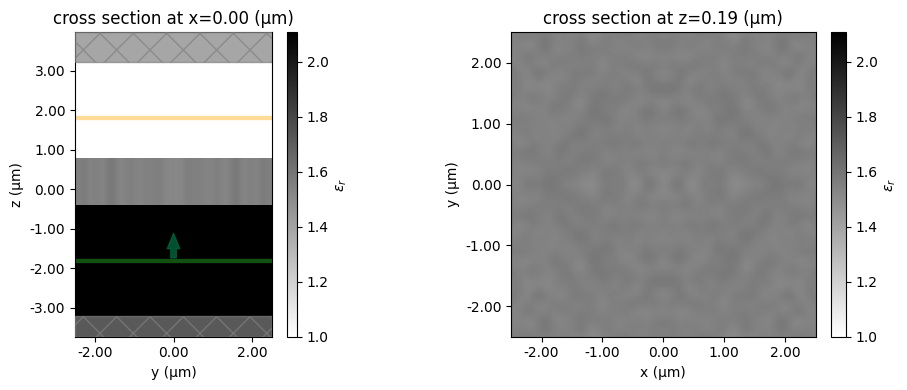

In [46]:
f, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4), tight_layout=True)
ax1 = sim.plot_eps(x=0, ax=ax1)
ax2 = sim.plot_eps(z=z_center_slab, ax=ax2)
plt.show()

We will also define an auxiliary function to post process and visualize the results.

In [47]:
def post_process(sim_data):
    """Post-process simulation data: compute efficiency, RMSE, and plot diffraction results."""
    order = TARGET_ORDER
    number_of_orders = NUM_TARGET_ORDERS

    # Extract data
    plot_data = sim_data["diffractionmonitor"]
    intensity_measured = plot_data.power
    theta, phi = plot_data.angles
    theta = theta.isel(f=0)
    phi = phi.isel(f=0)
    power_values = plot_data.power.isel(f=0)
    total_power = 0

    # Calculate diffraction orders
    order1, power1, desiredPower1 = [], [], []

    for xorder in intensity_measured.orders_x:
        for yorder in intensity_measured.orders_y:
            val = (
                sim_data["diffractionmonitor"]
                .power.isel(f=0)
                .sel(orders_x=xorder, orders_y=yorder)
                .values
            )
            total_power += val
            if (abs(xorder) <= order) and (abs(yorder) <= order):
                order1.append((int(xorder), int(yorder)))
                power1.append(val)
                desiredPower1.append(1 / number_of_orders)

    rmse = np.sqrt(
        (1 / number_of_orders) * np.sum((np.array(power1) - np.sum(power1) / number_of_orders) ** 2)
    )
    rmse *= 100  # to get percentage

    labels1 = [f"({x},{y})" for x, y in order1]

    # Create a figure with two subplots side by side
    fig = plt.figure(figsize=(10, 4))
    ax_polar = fig.add_subplot(1, 2, 1, projection="polar")
    ax_bar = fig.add_subplot(1, 2, 2)

    # --- Polar plot ---
    sc = ax_polar.scatter(phi, theta, c=power_values, cmap="hot_r")
    fig.colorbar(sc, ax=ax_polar, orientation="vertical", pad=0.1)
    ax_polar.set_title("Far-Field Diffraction Pattern", va="bottom")

    # --- Bar plot ---
    total_power = float(np.sum(power_values))
    ax_bar.bar(
        range(len(power1)),
        100 * np.array(power1) / total_power,
        color="tab:blue",
        label="Measured (nonzero)",
    )
    ax_bar.bar(
        range(len(desiredPower1)),
        np.array(desiredPower1) * 100,
        color="cyan",
        alpha=0.3,
        label="Desired",
    )
    ax_bar.legend()
    ax_bar.set_xticks(range(len(power1)))
    ax_bar.set_xticklabels(labels1, rotation=90, fontsize=8)
    ax_bar.set_xlabel("Diffraction Order (x,y)")
    ax_bar.set_title("Diffraction Monitor Power by Order")

    plt.tight_layout()
    plt.show()

    efficiency = sum(power1) / total_power

    print(f"Efficiency: {efficiency:.2f}")
    print(f"RMSE: {rmse:.2f}")

    return efficiency, rmse

## Normalization Simulation

We run a simulation with the flat substrate (no grating) to measure the total available
transmitted power, `power0`. This serves as our fixed reference for computing efficiency,
so the optimization target does not shift as the design changes.

In [48]:
sim_norm = td.Simulation(
    size=(length, length, Lz),
    grid_spec=td.GridSpec.auto(min_steps_per_wvl=min_steps_per_wvl),
    boundary_spec=td.BoundarySpec(
        x=td.Boundary(plus=td.Periodic(), minus=td.Periodic()),
        y=td.Boundary(plus=td.Periodic(), minus=td.Periodic()),
        z=td.Boundary(plus=td.PML(), minus=td.PML()),
    ),
    structures=[substrate],
    monitors=[diffractionmonitor],
    sources=[src],
    run_time=run_time,
)

sim_data_norm = web.run(sim_norm, task_name="normalization", verbose=True)
power0 = float(np.sum(sim_data_norm["diffractionmonitor"].power.values))
print(f"Reference power (power0): {power0:.4f}")

13:12:00 CEST Loading simulation from local cache. View cached task using web UI
              at                                                                
              ]8;id=425551;https://tidy3d.simulation.cloud/workbench?taskId=fdve-f0efd4b1-9fdc-407f-a948-45d9d24c62a3\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=336011;https://tidy3d.simulation.cloud/workbench?taskId=fdve-f0efd4b1-9fdc-407f-a948-45d9d24c62a3\taskId]8;;\]8;id=425551;https://tidy3d.simulation.cloud/workbench?taskId=fdve-f0efd4b1-9fdc-407f-a948-45d9d24c62a3\=]8;;\]8;id=474640;https://tidy3d.simulation.cloud/workbench?taskId=fdve-f0efd4b1-9fdc-407f-a948-45d9d24c62a3\fdve]8;;\]8;id=425551;https://tidy3d.simulation.cloud/workbench?taskId=fdve-f0efd4b1-9fdc-407f-a948-45d9d24c62a3\-f0efd4b1-9f]8;;\
              ]8;id=425551;https://tidy3d.simulation.cloud/workbench?taskId=fdve-f0efd4b1-9fdc-407f-a948-45d9d24c62a3\dc-407f-a948-45d9d24c62a3']8;;\.

Reference power (power0): 0.9675


## Objective Function

Next, we will define a function to analyze the [DiffractionMonitor](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.DiffractionMonitor.html) data and evaluate the total power inside the desired diffraction orders, along with a penalty to ensure equal distribution of the intensities.

In [49]:
def intensity_diff_fn(sim_data, weight_outside=0.1):
    """Returns a measure of the difference between desired and target intensity patterns."""
    power = sim_data["diffractionmonitor"].power

    # Total power at desired orders
    total_power = 0.0
    for ordersx in power.orders_x:
        for ordersy in power.orders_y:
            power_xy = power.sel(orders_x=ordersx, orders_y=ordersy)
            if abs(ordersx) <= TARGET_ORDER and abs(ordersy) <= TARGET_ORDER:
                total_power = total_power + power_xy

    # Adding the penalty for uneven distribution of the power, and also power at undesired orders
    cost = 0.0
    for ordersx in power.orders_x:
        for ordersy in power.orders_y:
            power_xy = power.sel(orders_x=ordersx, orders_y=ordersy)
            if abs(ordersx) <= TARGET_ORDER and abs(ordersy) <= TARGET_ORDER:
                cost = cost + (total_power / NUM_TARGET_ORDERS - power_xy) ** 2
            else:
                cost = cost + weight_outside * anp.abs(power_xy) ** 2

    return cost

### Loss Function

Finally, we can create our loss function, which takes as input the parameter list and beta, creates and runs the simulation object, processes the data, and returns the loss, including fabrication constraint penalties. This is the function that will be differentiated using autograd.

It extracts the diffraction orders from the [DiffractionMonitor](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.DiffractionMonitor.html), and first calculates the total power as the sum of the intensities of all desired diffraction orders. Next, the function adds to the cost function a penalty for the difference of each order with respect to the mean power, to enforce homogeneity. Finally, the power outside the desired orders is accounted for as a penalty to enforce high efficiency.

In [50]:
def loss_fn(params, beta, verbose=False):
    """Loss function for the design, the difference in intensity + the feature size penalty."""
    sim = make_sim(params, beta=beta)
    sim_data = web.run(sim, task_name="diffractive_beam_splitter", verbose=verbose)

    cost = intensity_diff_fn(sim_data)
    density = filter_project(params, beta)
    fab_penalty = erosion_dilation_penalty(density)

    res = cost**-1 - FAB_WEIGHT * fab_penalty

    # Extract per-order powers for monitoring (detached from autograd graph).
    power_da = sim_data["diffractionmonitor"].power.isel(f=0)
    pv = power_da.values
    orders_x = power_da.orders_x.values
    orders_y = power_da.orders_y.values

    order_powers = []
    order_labels = []
    target_sum = 0.0
    total_power = 0.0
    for i, ox in enumerate(orders_x):
        for j, oy in enumerate(orders_y):
            v = _to_float(pv[i, j])
            total_power += v
            if abs(ox) <= TARGET_ORDER and abs(oy) <= TARGET_ORDER:
                order_powers.append(v)
                order_labels.append((int(ox), int(oy)))
                target_sum += v

    aux_data = dict(
        objective=_to_float(cost),
        fab_penalty=_to_float(fab_penalty),
        efficiency=target_sum / total_power if total_power > 0 else 0.0,
        order_powers=np.array(order_powers),
        order_labels=order_labels,
    )

    return res, aux_data


loss_fn_val_grad = value_and_grad(loss_fn, has_aux=True)

Before running the optimization, we first check that everything is working correctly.

In [51]:
(val, grad), aux_data = loss_fn_val_grad(params0, beta0, verbose=True)

print(f"Loss value (maximize): {val:.4f}")
print(f"  Cost (minimize): {aux_data['objective']:.4e}")
print(f"  Fab penalty: {aux_data['fab_penalty']:.4e}")
print(f"  Efficiency: {aux_data['efficiency']:.4f}")

13:12:01 CEST Loading simulation from local cache. View cached task using web UI
              at                                                                
              ]8;id=368403;https://tidy3d.simulation.cloud/workbench?taskId=fdve-9f79657e-766a-443e-8738-38f3eac8e9d0\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=705829;https://tidy3d.simulation.cloud/workbench?taskId=fdve-9f79657e-766a-443e-8738-38f3eac8e9d0\taskId]8;;\]8;id=368403;https://tidy3d.simulation.cloud/workbench?taskId=fdve-9f79657e-766a-443e-8738-38f3eac8e9d0\=]8;;\]8;id=891693;https://tidy3d.simulation.cloud/workbench?taskId=fdve-9f79657e-766a-443e-8738-38f3eac8e9d0\fdve]8;;\]8;id=368403;https://tidy3d.simulation.cloud/workbench?taskId=fdve-9f79657e-766a-443e-8738-38f3eac8e9d0\-9f79657e-76]8;;\
              ]8;id=368403;https://tidy3d.simulation.cloud/workbench?taskId=fdve-9f79657e-766a-443e-8738-38f3eac8e9d0\6a-443e-8738-38f3eac8e9d0']8;;\.

13:12:05 CEST Started working on Batch containing 1 tasks.

13:12:06 CEST No Flexcredit cost for batch as all simulations were restored from
              local cache.

              Use 'Batch.real_cost()' to get the billed FlexCredit cost after   
              completion.

diffractive_beam_splitter_a... → success ━━━━━━━━━━━━━━━━━━━━━━━━━ 100% 0:00:00

              Batch complete.

↓ autograd_sim_vjp.hdf5 ━━━━━━━━━━━━━━━ 100.0% • 2.6/2.6 MB • 2.4 MB/s • 0:00:00

Loss value (maximize): 0.8790
  Cost (minimize): 9.2712e-01
  Fab penalty: 9.9816e-01
  Efficiency: 0.9999


It is also a good sanity check to look at the gradients and confirm they are not all 0.

In [52]:
print(f"Gradient norm: {np.linalg.norm(grad):.3e}")
print(f"Gradient range: [{np.min(grad):.3e}, {np.max(grad):.3e}]")

Gradient norm: 1.249e-03
Gradient range: [-1.059e-05, 5.702e-06]


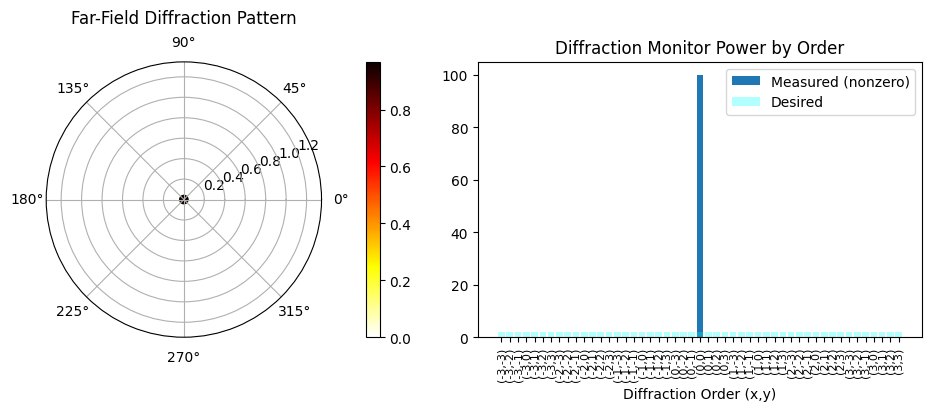

Efficiency: 1.00
RMSE: 13.68


(np.float64(1.0), np.float64(13.679721678400911))

In [53]:
post_process(aux_data.get("sim_data", sim_data_norm))

## Optimize Device

Now we are finally ready to optimize our device.

As in the other tutorials, we use Tidy3D's Adam optimizer. We negate the gradient at each step since we are maximizing the objective (which is `cost^(-1)`).

The binarization strength `beta` is gradually increased over the course of the optimization, encouraging the design to converge toward a fabricable binary structure.

In [54]:
from tidy3d.plugins.autograd import adam, apply_updates

num_steps = 80
learning_rate = 0.3
optimizer = adam(learning_rate=learning_rate)

params = params0.copy()
opt_state = optimizer.init(params)

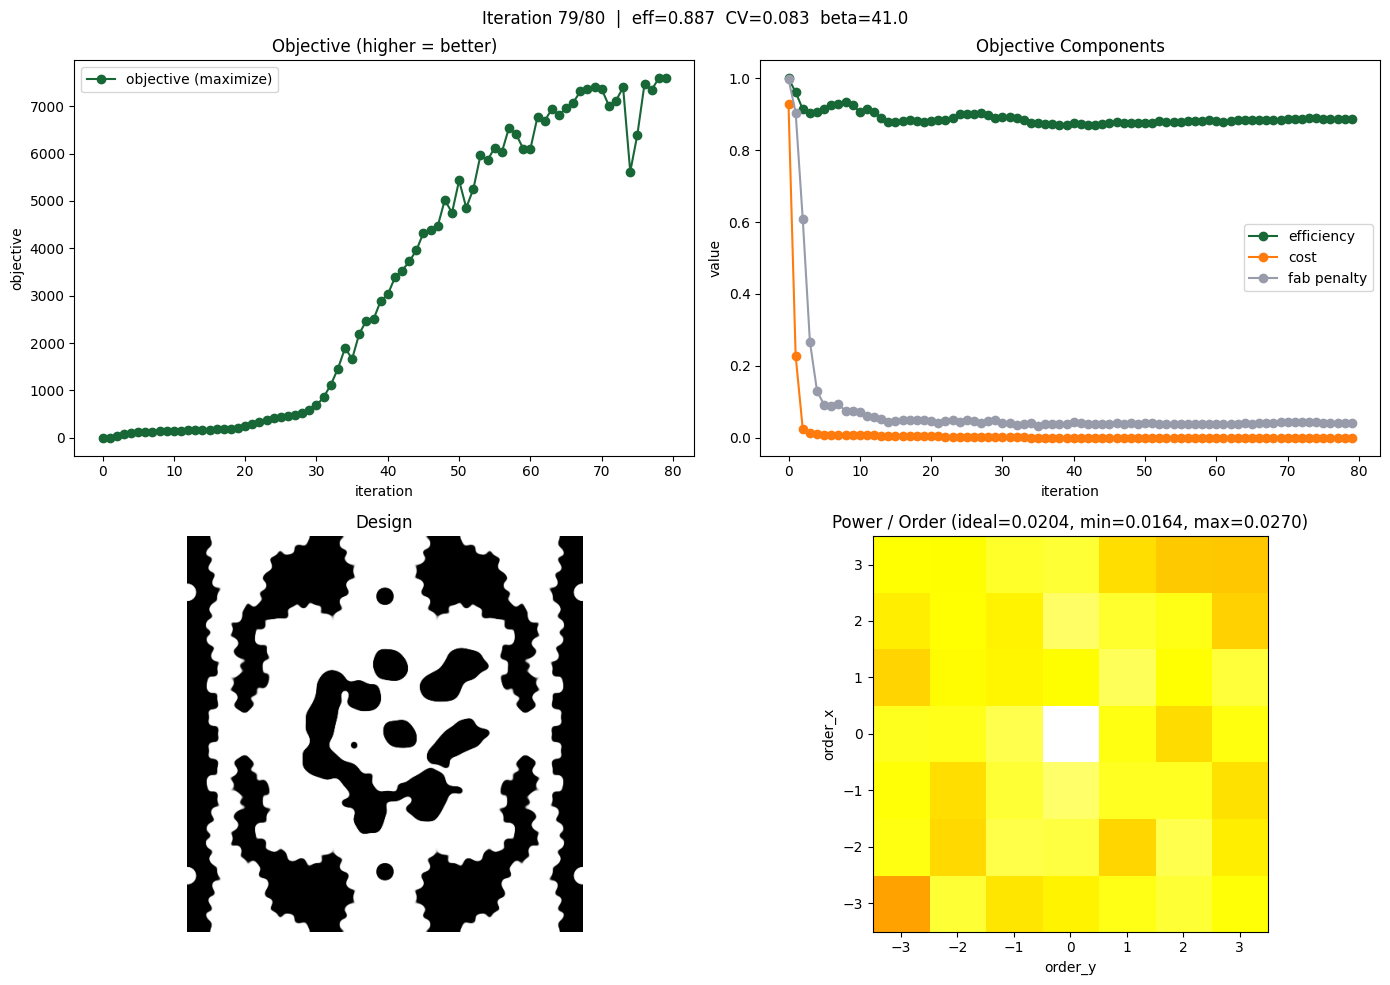

In [55]:
# gradually increase the binarization strength over iteration
beta = beta0
beta_increment = 0.5

history = dict(
    loss=[],
    objective=[],
    efficiency=[],
    fab_penalty=[],
    betas=[],
    params=[],
    order_powers=[],
)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for i in range(num_steps):
    # compute gradient and current loss function value
    (loss, gradient), aux_data = loss_fn_val_grad(params, beta)

    # record history
    history["loss"].append(loss)
    history["objective"].append(aux_data["objective"])
    history["efficiency"].append(aux_data["efficiency"])
    history["fab_penalty"].append(aux_data["fab_penalty"])
    history["betas"].append(beta)
    history["params"].append(params.copy())
    history["order_powers"].append(aux_data["order_powers"])

    # per-order power statistics
    op = aux_data["order_powers"]
    op_fracs = op / op.sum()
    ideal_frac = 1.0 / NUM_TARGET_ORDERS
    cv = np.std(op) / (np.mean(op) + 1e-20)

    # log output
    print(f"step {i}/{num_steps}")
    print(f"  loss (maximize) = {loss:.3e}")
    print(f"  cost (minimize) = {aux_data['objective']:.3e}")
    print(f"  efficiency      = {aux_data['efficiency']:.3f}")
    print(f"  fab_penalty     = {aux_data['fab_penalty']:.3e}")
    print(f"  beta            = {beta:.2f}")
    print(f"  |gradient|      = {np.linalg.norm(gradient):.3e}")
    print(
        f"  order powers: min={op.min():.4f}  max={op.max():.4f}  mean={op.mean():.4f}  CV={cv:.3f}"
    )

    # NEGATE gradient because we are MAXIMIZING
    updates, opt_state = optimizer.update(-gradient, opt_state, params)
    params = np.clip(apply_updates(params, updates), 0.0, 1.0)

    # update beta
    beta += beta_increment

    # --- Live-updating progress plot ---
    for ax in axes.flat:
        ax.clear()

    fig.suptitle(
        f"Iteration {i}/{num_steps}  |  eff={aux_data['efficiency']:.3f}  "
        f"CV={cv:.3f}  beta={beta:.1f}"
    )

    # Top-left: loss history
    axes[0, 0].plot(history["loss"], "o-", label="objective (maximize)")
    axes[0, 0].set_xlabel("iteration")
    axes[0, 0].set_ylabel("objective")
    axes[0, 0].set_title("Objective (higher = better)")
    axes[0, 0].legend()

    # Top-right: objective components
    axes[0, 1].plot(history["efficiency"], "o-", label="efficiency")
    axes[0, 1].plot(history["objective"], "o-", label="cost")
    axes[0, 1].plot(history["fab_penalty"], "o-", label="fab penalty")
    axes[0, 1].set_xlabel("iteration")
    axes[0, 1].set_ylabel("value")
    axes[0, 1].set_title("Objective Components")
    axes[0, 1].legend()

    # Bottom-left: design pattern
    density = filter_project(params, beta)
    axes[1, 0].imshow(np.flipud(1 - density.T), cmap="gray")
    axes[1, 0].axis("off")
    axes[1, 0].set_title("Design")

    # Bottom-right: diffraction order power heatmap
    grid_size = 2 * TARGET_ORDER + 1
    order_grid = np.zeros((grid_size, grid_size))
    for (ox, oy), pwr in zip(aux_data["order_labels"], aux_data["order_powers"]):
        order_grid[ox + TARGET_ORDER, oy + TARGET_ORDER] = pwr
    order_grid_norm = order_grid / (order_grid.sum() + 1e-20)

    im = axes[1, 1].imshow(
        order_grid_norm,
        cmap="hot",
        vmin=0,
        extent=[-TARGET_ORDER - 0.5, TARGET_ORDER + 0.5, -TARGET_ORDER - 0.5, TARGET_ORDER + 0.5],
        origin="lower",
    )
    axes[1, 1].set_xlabel("order_y")
    axes[1, 1].set_ylabel("order_x")
    axes[1, 1].set_title(
        f"Power / Order (ideal={ideal_frac:.4f}, "
        f"min={op_fracs.min():.4f}, max={op_fracs.max():.4f})"
    )

    plt.tight_layout()
    clear_output(wait=True)
    display(fig)

plt.show()

## Analyze Results

First, let's plot the objective function history, and the final permittivity distribution.

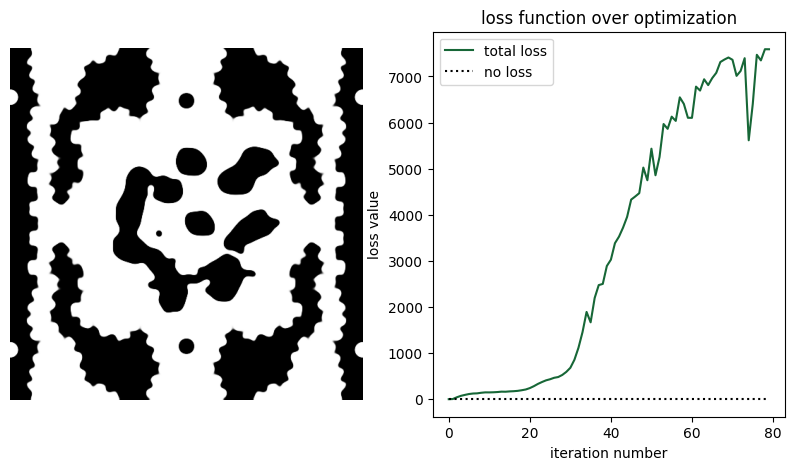

In [56]:
params_final = history["params"][-1]
beta_final = history["betas"][-1]

fig, axe = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))

density = filter_project(params_final, beta_final)

axe[0].imshow(np.flipud(1 - density.T), cmap="gray")
axe[0].axis("off")

axe[1].plot(history["loss"], label="total loss")
axe[1].plot(np.zeros_like(history["loss"]), linestyle=":", color="k", label="no loss")

axe[1].set_xlabel("iteration number")
axe[1].set_ylabel("loss value")

axe[1].set_title("loss function over optimization")
axe[1].legend()

plt.show()

Now, we can run the final simulation.

In [57]:
sim_final = make_sim(params_final, beta_final)
sim_data_final = web.run(sim_final, task_name="Inspect")

19:38:44 CEST Created task 'Inspect' with resource_id                           
              'fdve-40de74cf-76a2-4780-8309-77caf6007479' and task_type 'FDTD'.

              View task using web UI at                                         
              ]8;id=704288;https://tidy3d.simulation.cloud/workbench?taskId=fdve-40de74cf-76a2-4780-8309-77caf6007479\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=454934;https://tidy3d.simulation.cloud/workbench?taskId=fdve-40de74cf-76a2-4780-8309-77caf6007479\taskId]8;;\]8;id=704288;https://tidy3d.simulation.cloud/workbench?taskId=fdve-40de74cf-76a2-4780-8309-77caf6007479\=]8;;\]8;id=869085;https://tidy3d.simulation.cloud/workbench?taskId=fdve-40de74cf-76a2-4780-8309-77caf6007479\fdve]8;;\]8;id=704288;https://tidy3d.simulation.cloud/workbench?taskId=fdve-40de74cf-76a2-4780-8309-77caf6007479\-40de74cf-76]8;;\
              ]8;id=704288;https://tidy3d.simulation.cloud/workbench?taskId=fdve-40de74cf-76a2-4780-8309-77caf6007479\a2-4780-8309-77caf6007479']8;;\.

              Task folder: ]8;id=45613;https://tidy3d.simulation.cloud/folders/folder-df61810d-cad6-4474-8ea9-e4f00d5dfcb0\'default']8;;\.

↑ simulation.hdf5.gz ━━━━━━━━━━━━━━━━━━━━━ 100.0% • 532.3/532.3 kB • ? • 0:00:00

19:38:56 CEST Estimated FlexCredit cost: 0.781. Minimum cost depends on task    
              execution details. Use 'web.real_cost(task_id)' to get the billed 
              FlexCredit cost after a simulation run.

...

19:40:15 CEST early shutoff detected at 75%, exiting.

              status = success

              View simulation result at                                         
              ]8;id=401598;https://tidy3d.simulation.cloud/workbench?taskId=fdve-40de74cf-76a2-4780-8309-77caf6007479\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=288107;https://tidy3d.simulation.cloud/workbench?taskId=fdve-40de74cf-76a2-4780-8309-77caf6007479\taskId]8;;\]8;id=401598;https://tidy3d.simulation.cloud/workbench?taskId=fdve-40de74cf-76a2-4780-8309-77caf6007479\=]8;;\]8;id=58513;https://tidy3d.simulation.cloud/workbench?taskId=fdve-40de74cf-76a2-4780-8309-77caf6007479\fdve]8;;\]8;id=401598;https://tidy3d.simulation.cloud/workbench?taskId=fdve-40de74cf-76a2-4780-8309-77caf6007479\-40de74cf-76]8;;\
              ]8;id=401598;https://tidy3d.simulation.cloud/workbench?taskId=fdve-40de74cf-76a2-4780-8309-77caf6007479\a2-4780-8309-77caf6007479']8;;\.

↓ simulation_data.hdf5.gz ━━━━━━━━━━━━ 100.0% • 551.8/551.8 • 1.4 MB/s • 0:00:00
                                                kB         

19:40:18 CEST Loading results from simulation_data.hdf5

As we can see, although starting with a random distribution, we can achieve good figures of merit when compared with the reference [paper](https://www.spiedigitallibrary.org/conference-proceedings-of-spie/11261/1126115/Adjoint-method-and-inverse-design-for-diffractive-beam-splitters/10.1117/12.2543367.short).

Although the performance is good, the minimum feature sizes might be too small for some fabrication systems. In that case, it is possible to increase the radius parameter to help enforce larger feature sizes.

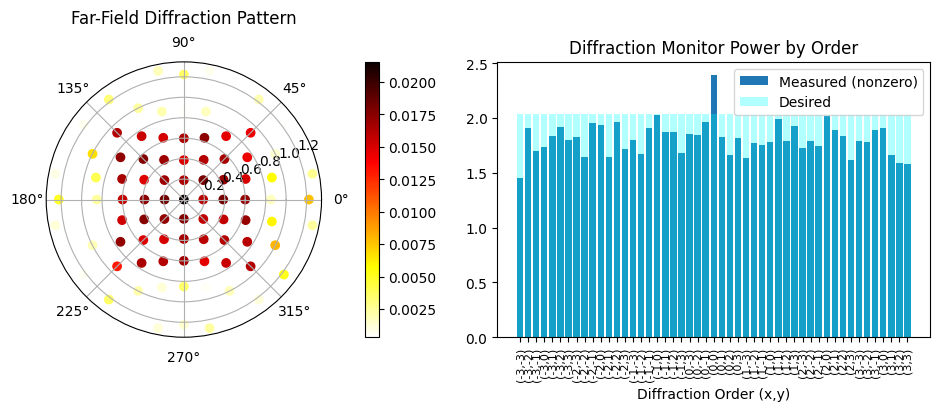

Efficiency: 0.89
RMSE: 0.14


In [58]:
efficiency, rmse = post_process(sim_data_final)